# BMW 중고차량 가격예측

# 0 라이브러리와 데이터셋 불러오기

## 0-1-1. 라이브러리 불러오기

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#시각화 스타일
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 10


0-1-2. 데이터 불러오기

In [12]:
from google.colab import files
uploaded = files.upload()  # 이 셀 실행하면 파일 선택창 뜸

import pandas as pd
df_original = pd.read_csv('bmw.csv')


Saving bmw.csv to bmw (2).csv


In [13]:
#작업용 복사본
df = df_original.copy()


# 데이터 기본 정보
print(df.shape) #(10781, 9)
print('======data.head(10)=========')
print(df.head(10))
print('======data.info()-==========')
# model(obj) | year(int)  price(int) transmission(obj)  mileage(int) fuelType(obj)  tax(int)   mpg(flo)  engineSize(flo) // dtypes: float64(2), int64(4), object(3)
print(df.info())
print('======data.isna=============') #isna(all false)
print(df.sum().isnull())

(10781, 9)
======data.head(10)=========
       model  year  price transmission  mileage fuelType  tax   mpg  \
0   5 Series  2014  11200    Automatic    67068   Diesel  125  57.6   
1   6 Series  2018  27000    Automatic    14827   Petrol  145  42.8   
2   5 Series  2016  16000    Automatic    62794   Diesel  160  51.4   
3   1 Series  2017  12750    Automatic    26676   Diesel  145  72.4   
4   7 Series  2014  14500    Automatic    39554   Diesel  160  50.4   
5   5 Series  2016  14900    Automatic    35309   Diesel  125  60.1   
6   5 Series  2017  16000    Automatic    38538   Diesel  125  60.1   
7   2 Series  2018  16250       Manual    10401   Petrol  145  52.3   
8   4 Series  2017  14250       Manual    42668   Diesel   30  62.8   
9   5 Series  2016  14250    Automatic    36099   Diesel   20  68.9   

   engineSize  
0         2.0  
1         2.0  
2         3.0  
3         1.5  
4         3.0  
5         2.0  
6         2.0  
7         1.5  
8         2.0  
9         2.0  
==

In [14]:
print(df.shape)

(10781, 9)


#1. EDA

## 1-1. 각 변수의 분포 분석

1-1-1. 수치형 변수 분포(히스토그램)

In [15]:
# 수치형 변수들 통계
df = df_original.copy()
print(df.shape)
df.describe()

(10781, 9)


,year,price,mileage,tax,mpg,engineSize
count,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000
mean,2017.078935,22733.408867,25496.986550,131.702068,56.399035,2.167767
std,2.349038,11415.528189,25143.192559,61.510755,31.336958,0.552054
min,1996.000000,1200.000000,1.000000,0.000000,5.500000,0.000000
25%,2016.000000,14950.000000,5529.000000,135.000000,45.600000,2.000000
50%,2017.000000,20462.000000,18347.000000,145.000000,53.300000,2.000000
75%,2019.000000,27940.000000,38206.000000,145.000000,62.800000,2.000000
max,2020.000000,123456.000000,214000.000000,580.000000,470.800000,6.600000


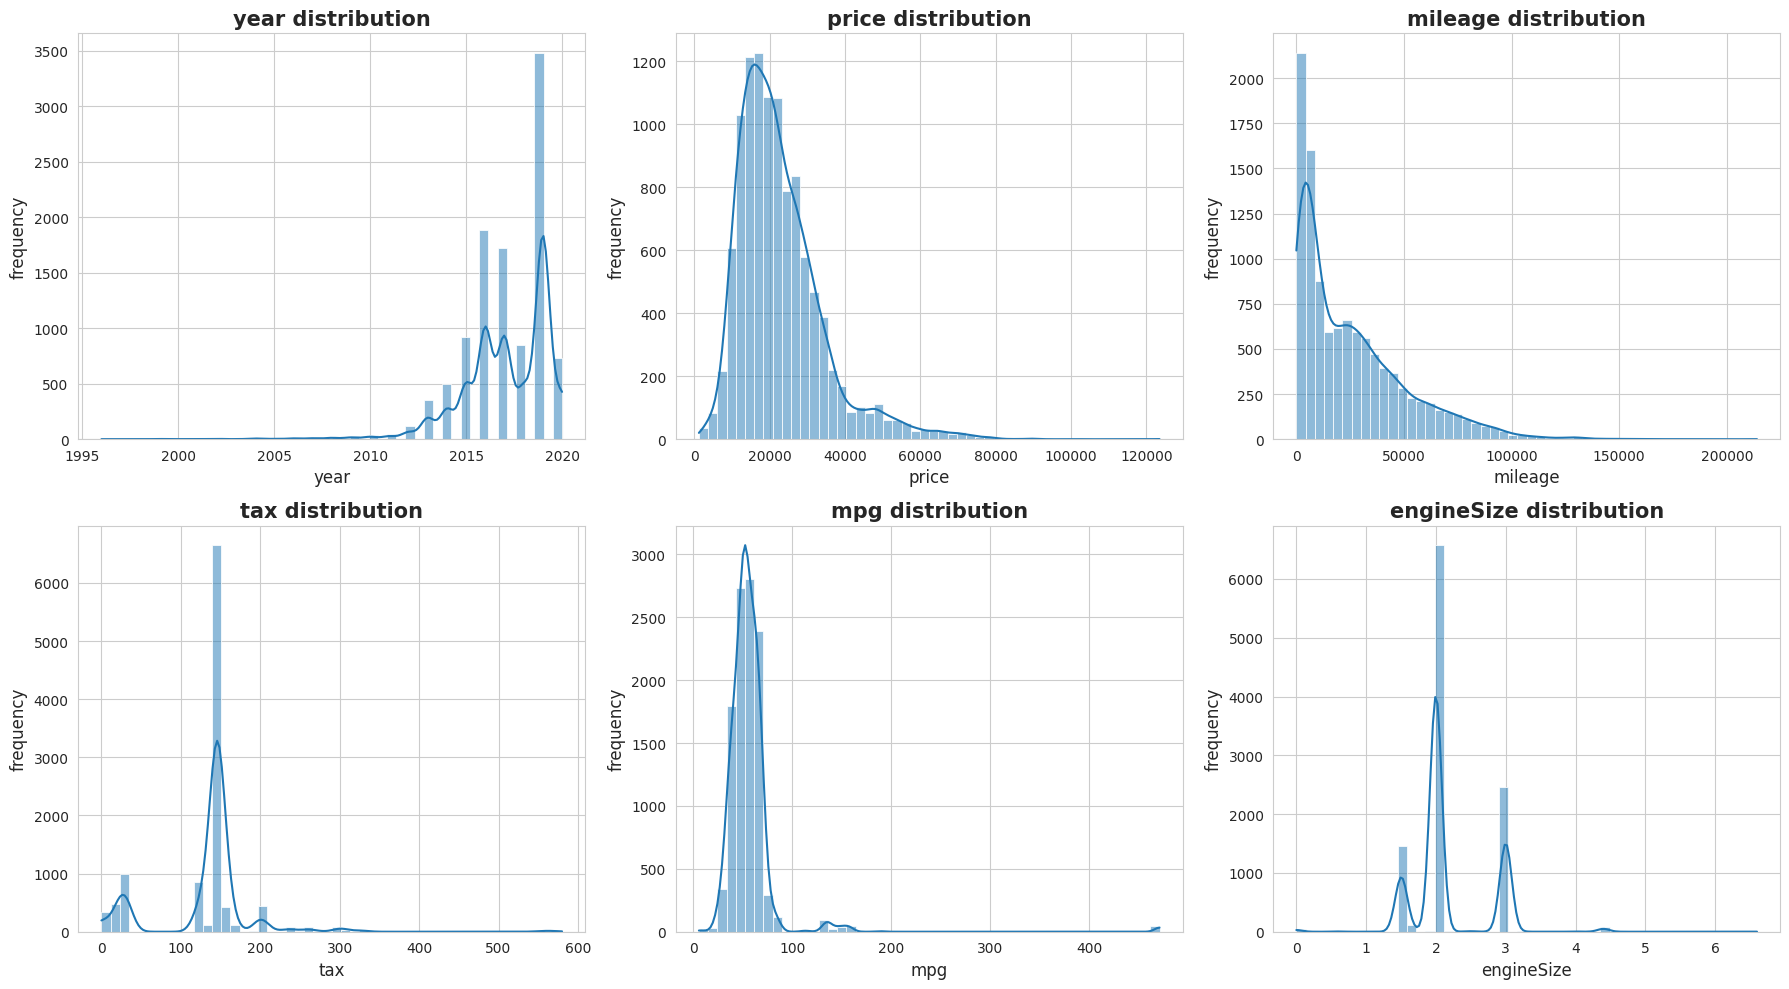

In [16]:
# 수치형 변수들 히스토그램
numeric_vars = ['year','price','mileage','tax','mpg','engineSize']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_vars):
    sns.histplot(data=df, x=col, kde=True, bins=50, ax=axes[idx])
    axes[idx].set_title(f'{col} distribution', fontsize=15, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=12)
    axes[idx].set_ylabel('frequency', fontsize=12)

plt.tight_layout()
plt.show()


In [17]:
print(df.shape)

(10781, 9)


1-1-2. 범주형 변수 분포(막대그래프)

In [18]:
# 범주형 변수들 통계
df.describe(include='object')

,model,transmission,fuelType
count,10781,10781,10781
unique,24,3,5
top,3 Series,Semi-Auto,Diesel
freq,2443,4666,7027


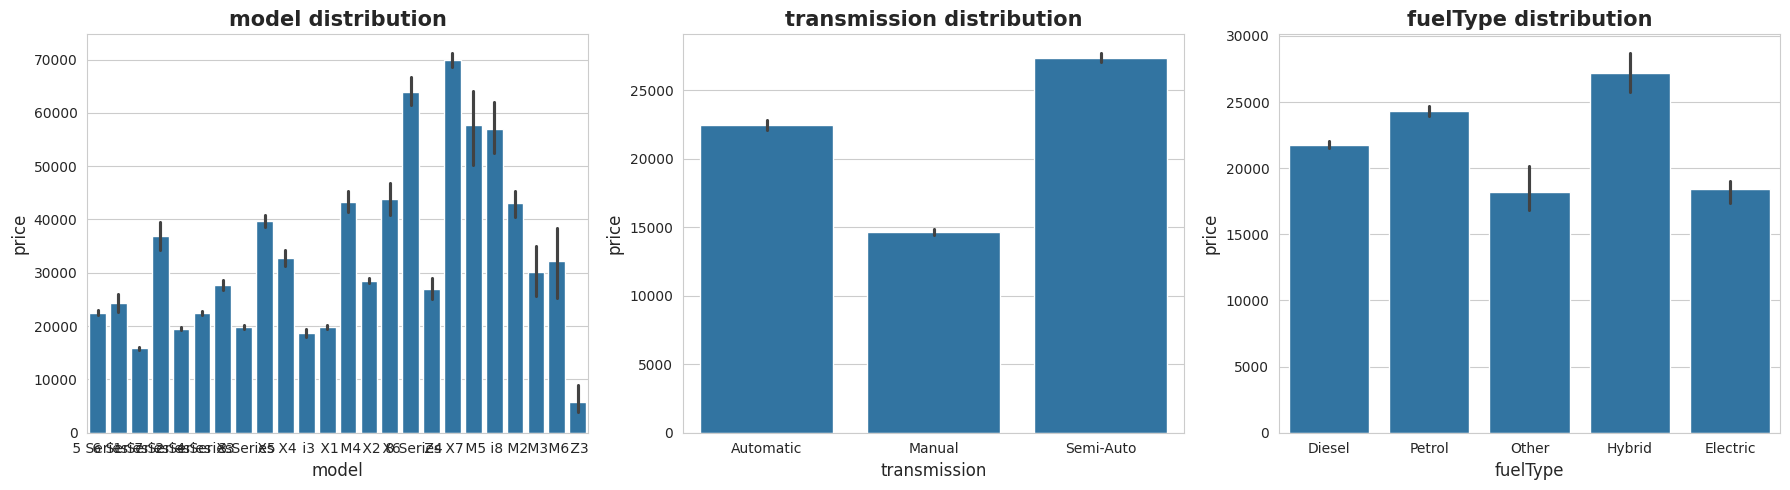

In [19]:
#범주형 변수들 막대그래프
categorical_vars = ['model','transmission','fuelType']

flg, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for idx, col in enumerate(categorical_vars):
    sns.barplot(data=df, x=col, y='price', ax=axes[idx])
    axes[idx].set_title(f'{col} distribution', fontsize=15, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=12)
    axes[idx].set_ylabel('price', fontsize=12)

plt.tight_layout()
plt.show()



In [20]:
print(df.shape)

(10781, 9)


## 1-2. 이상치 탐지

In [21]:
df = df_original.copy()

1-2-1. 박스플롯

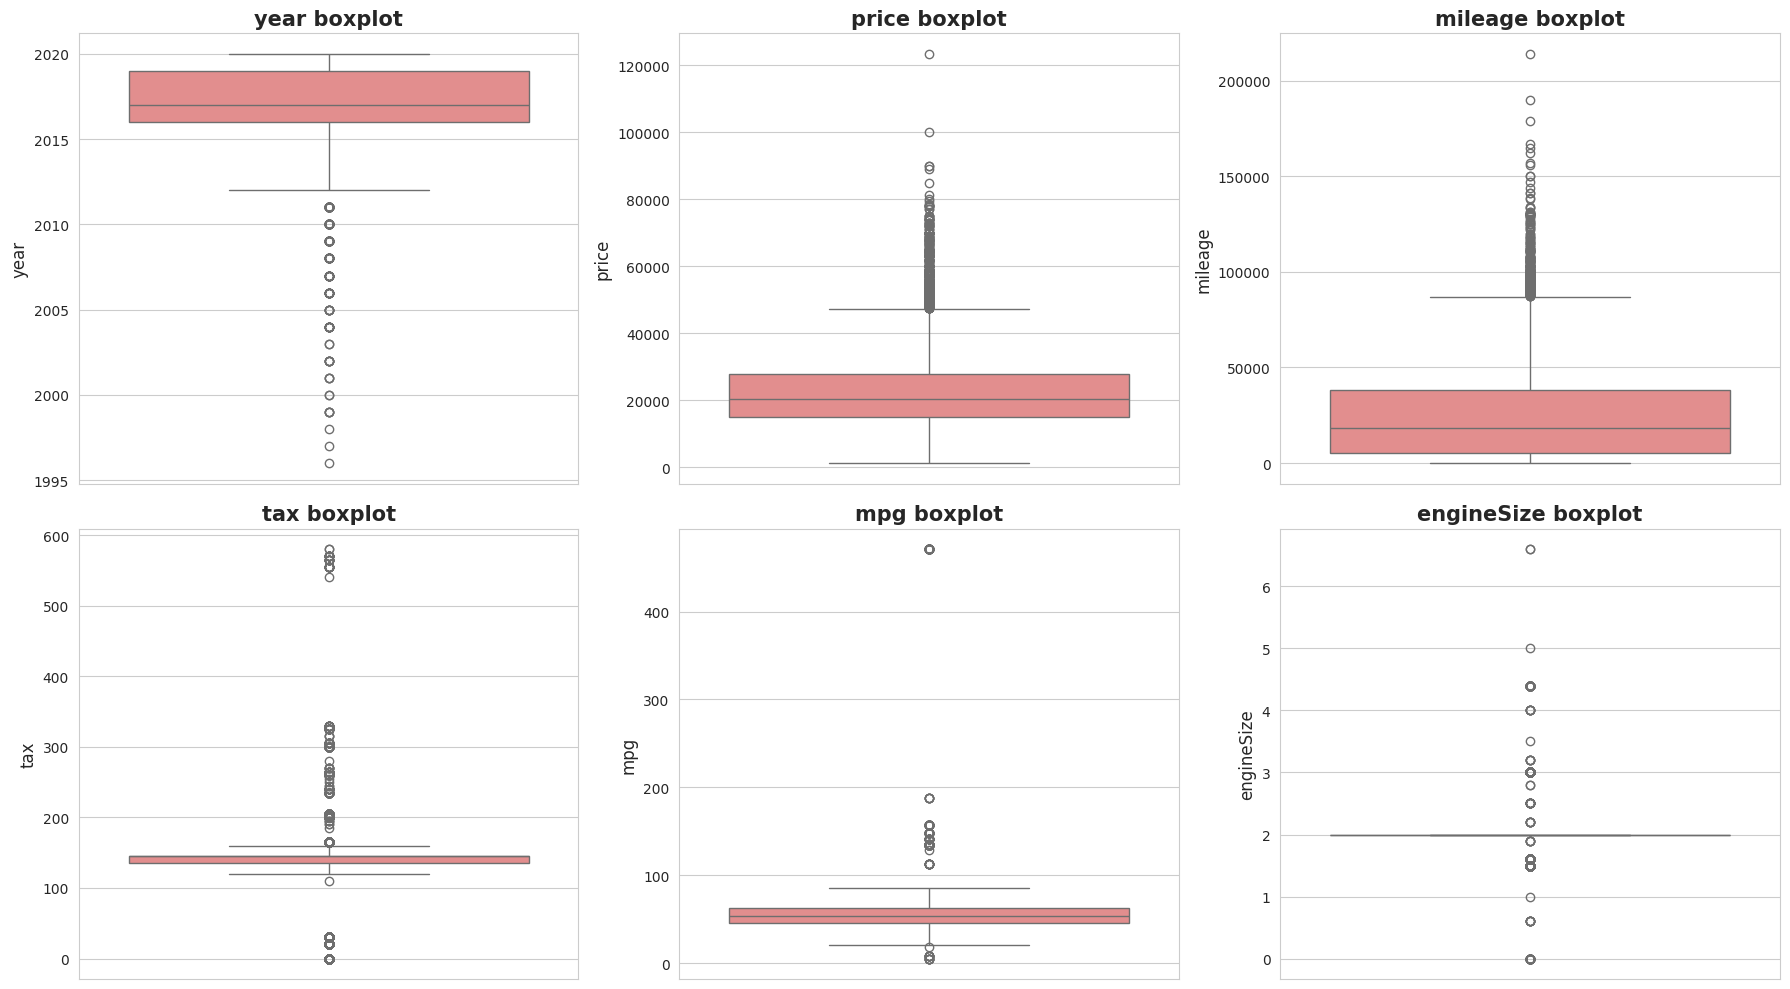

In [22]:
# 수치형 변수 박스플롯
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_vars):
    sns.boxplot(data=df, y=col, ax=axes[idx], color='lightcoral')
    axes[idx].set_title(f'{col} boxplot', fontsize=15, fontweight='bold')
    axes[idx].set_ylabel(col, fontsize=12)

plt.tight_layout()
plt.show()

1-2-2. IQR

In [23]:
# 수치형변수 IQR
def detect_outliers_IQR(data, column):
  Q1 = data[column].quantile(0.25)
  Q3 = data[column].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

  print(f"\n[{column}] 이상치 정보:")
  print(f' -하한값: {lower_bound}')
  print(f' -상한값: {upper_bound}')
  print(f' -이상치 개수: {len(outliers)}({len(outliers)/len(data)*100:.2f}%)')

  return outliers

  # 각 변수별 이상치 탐지
numeric_vars = ['year','price','mileage','tax','mpg','engineSize']
for col in numeric_vars:
    outliers = detect_outliers_IQR(df,col)
print(df.shape)


[year] 이상치 정보:
 -하한값: 2011.5
 -상한값: 2023.5
 -이상치 개수: 213(1.98%)

[price] 이상치 정보:
 -하한값: -4535.0
 -상한값: 47425.0
 -이상치 개수: 484(4.49%)

[mileage] 이상치 정보:
 -하한값: -43486.5
 -상한값: 87221.5
 -이상치 개수: 296(2.75%)

[tax] 이상치 정보:
 -하한값: 120.0
 -상한값: 160.0
 -이상치 개수: 2733(25.35%)

[mpg] 이상치 정보:
 -하한값: 19.800000000000008
 -상한값: 88.6
 -이상치 개수: 275(2.55%)

[engineSize] 이상치 정보:
 -하한값: 2.0
 -상한값: 2.0
 -이상치 개수: 4206(39.01%)
(10781, 9)


1-2-3. z-score

In [24]:
from scipy import stats

def detect_outliers_zscore(df, column, threshold = 3):
  z_score = np.abs(stats.zscore(df[column].dropna()))
  outliers_count = (z_score > threshold).sum()

  print(f"[{column}] Z-Score 이상치: {outliers_count}개 ({outliers_count/len(df)*100:.2f}%)")

  return outliers_count

for col in numeric_vars:
    detect_outliers_zscore(df, col)

[year] Z-Score 이상치: 162개 (1.50%)
[price] Z-Score 이상치: 201개 (1.86%)
[mileage] Z-Score 이상치: 117개 (1.09%)
[tax] Z-Score 이상치: 79개 (0.73%)
[mpg] Z-Score 이상치: 95개 (0.88%)
[engineSize] Z-Score 이상치: 135개 (1.25%)


## 1-3. 상관관계 분석

1-3-1. 히트맵

In [25]:
df = df_original.copy()
print(df.shape)

(10781, 9)


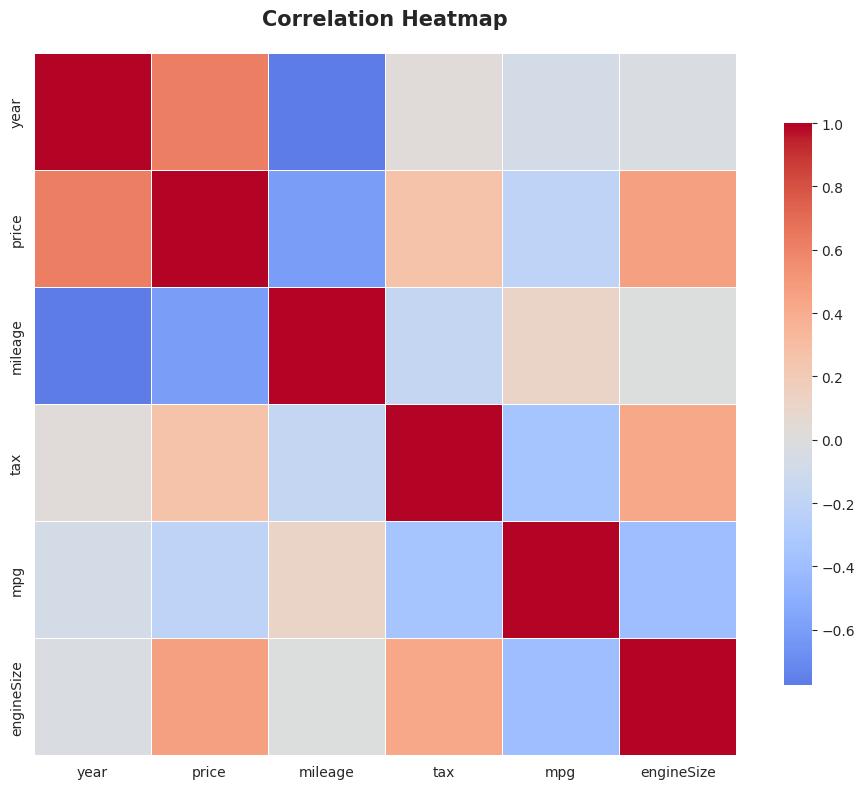


=======가격과의 상관계수=========
price         1.000000
year          0.623756
engineSize    0.460196
tax           0.263484
mpg          -0.204882
mileage      -0.605397
Name: price, dtype: float64


In [26]:
# 수치형 변수들 간의 상관관계

plt.figure(figsize=(10,8))

correlation_matrix = df[numeric_vars].corr()

sns.heatmap(correlation_matrix, fmt='2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=15, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()


# 가격과 수치형변수들의 피어슨 상관계수
price_corr = correlation_matrix['price'].sort_values(ascending=False)
print('\n=======가격과의 상관계수=========')
print(price_corr)

1-3-2. 산점도 행렬

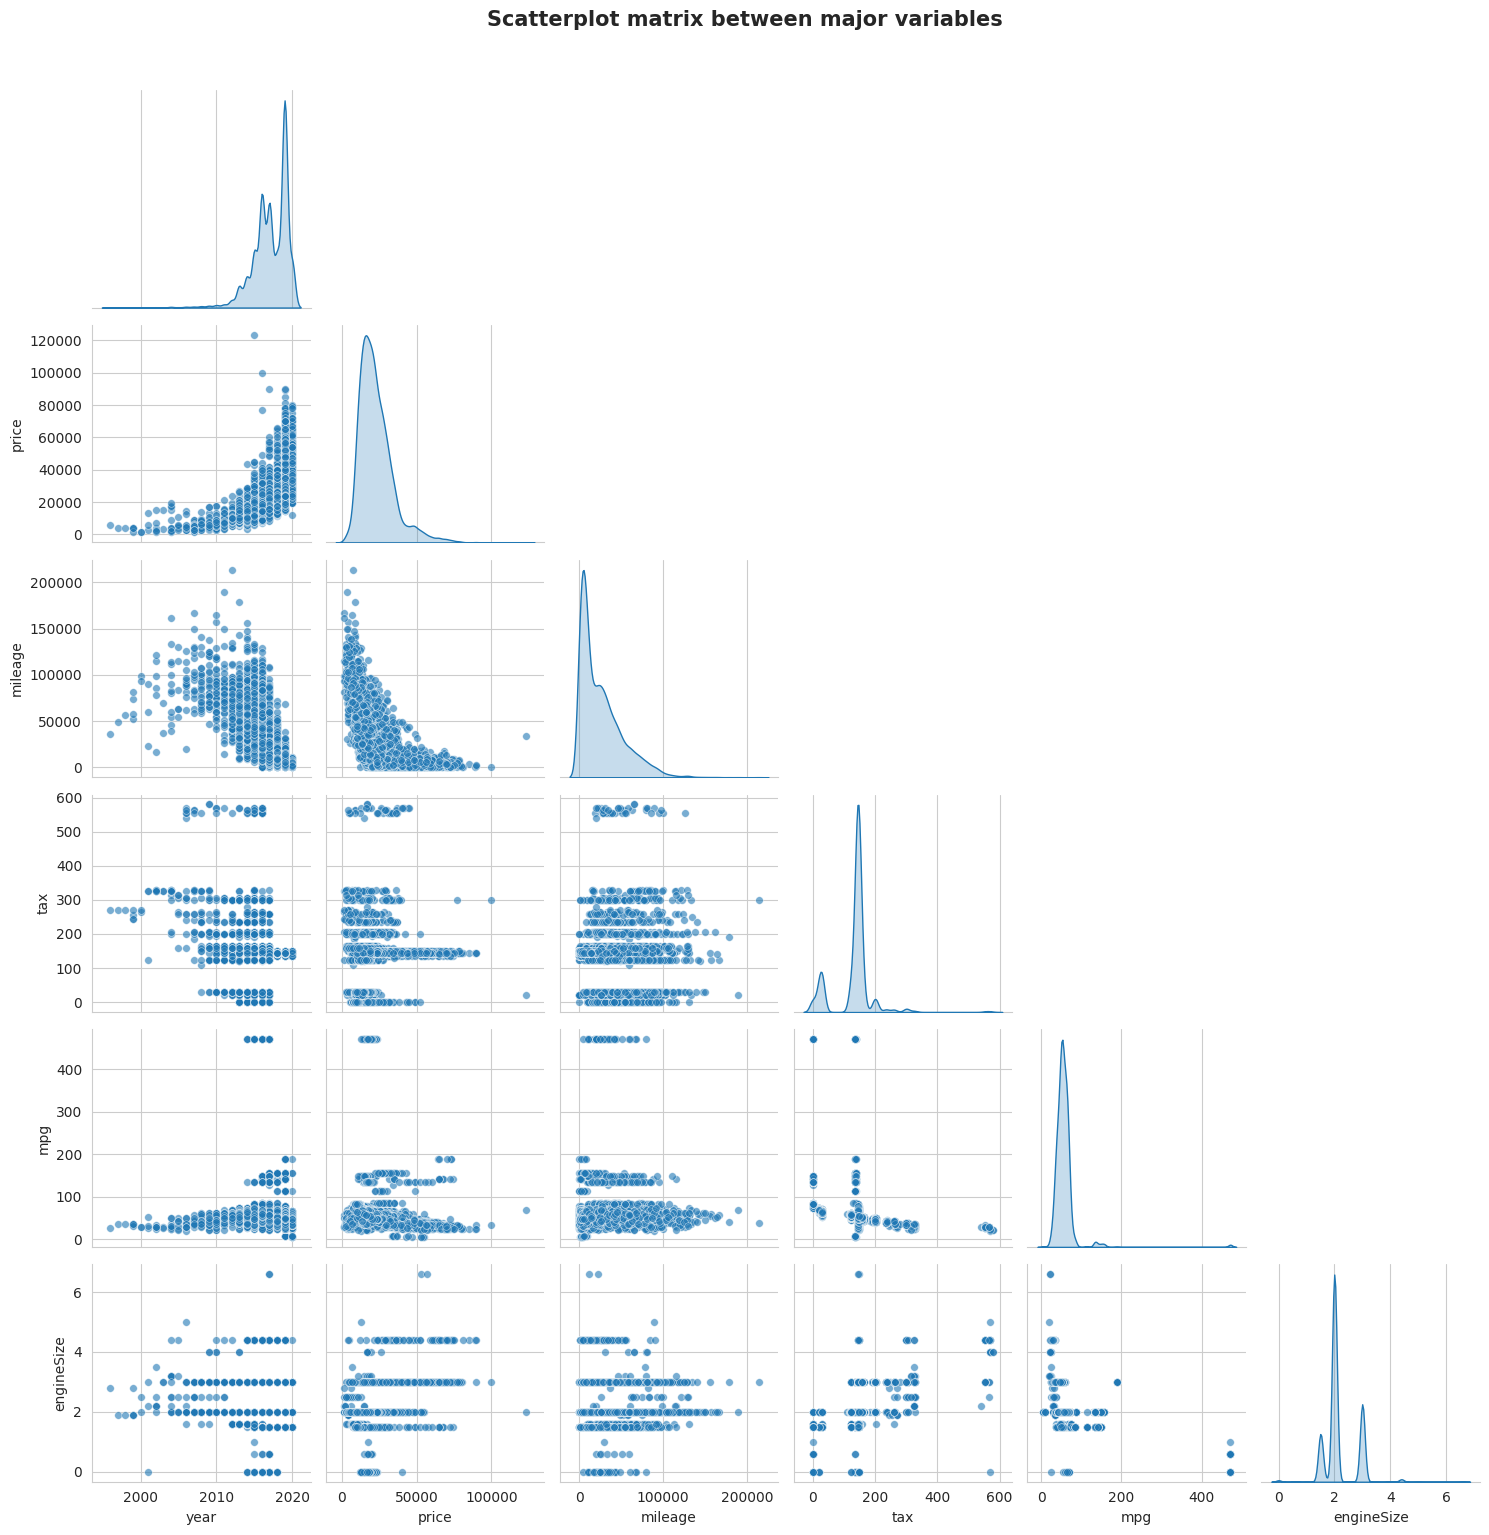

(10781, 9)


In [27]:
# 주요 변수들 간의 관계
sns.pairplot(df[numeric_vars], diag_kind='kde', plot_kws={'alpha':0.6, 's':30}, corner=True)

plt.suptitle('Scatterplot matrix between major variables', fontsize=15, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print(df.shape)


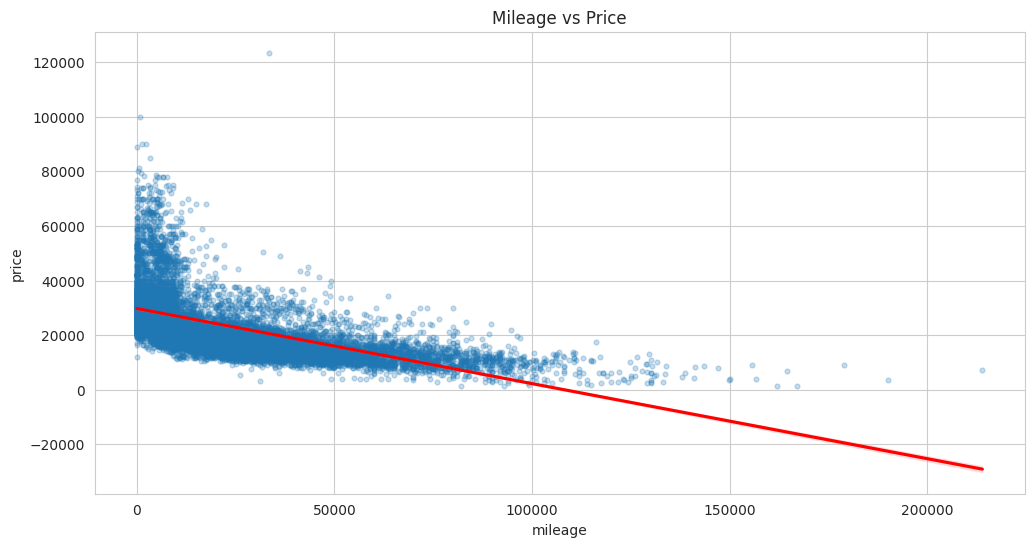

In [28]:
# mileage - price
sns.regplot(data=df, x="mileage", y="price", scatter_kws={"alpha":0.25, "s":12}, line_kws={"color":"red"})
plt.title("Mileage vs Price")
plt.show()

1-3-3 범주형 변수별 가격 분포

In [29]:
df=df_original.copy()
print(df.shape)
df.describe(include='object')

(10781, 9)


,model,transmission,fuelType
count,10781,10781,10781
unique,24,3,5
top,3 Series,Semi-Auto,Diesel
freq,2443,4666,7027


=======변속기 종류별 가격 분포=========


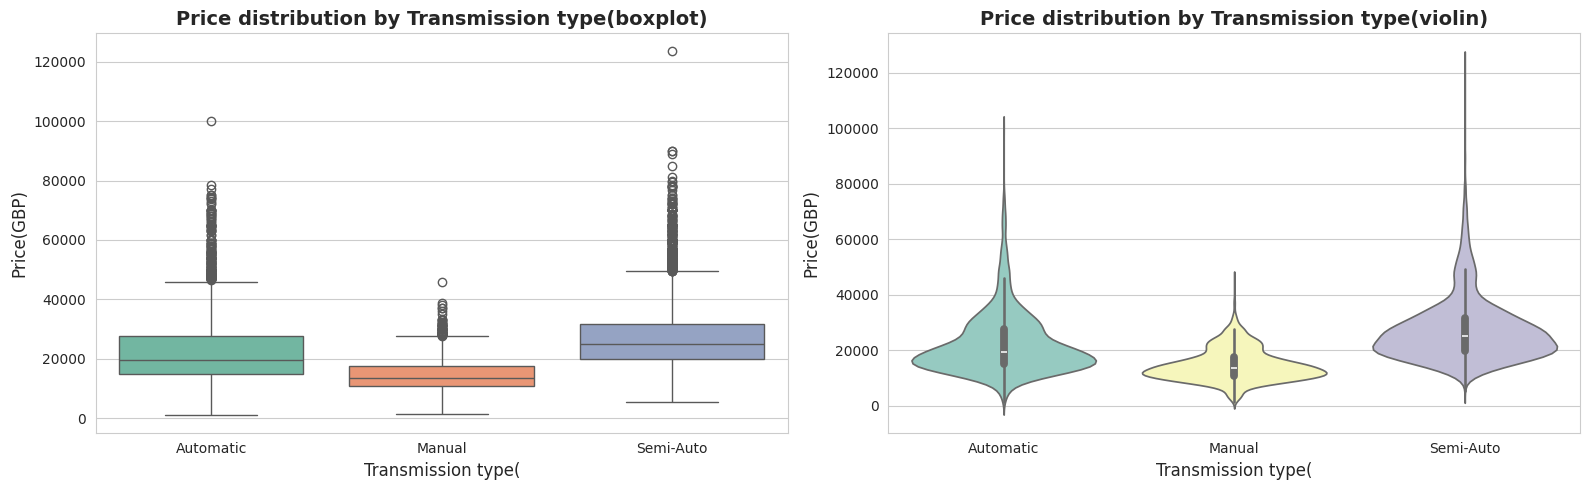

               count          mean           std     min       25%      50%  \
transmission                                                                  
Automatic     3588.0  22419.023969  11189.971319  1200.0  14973.75  19490.0   
Manual        2527.0  14637.451128   5725.267639  1445.0  10703.00  13500.0   
Semi-Auto     4666.0  27359.747964  11406.820313  5299.0  19795.75  24990.0   

                   75%       max  
transmission                      
Automatic     27500.00   99950.0  
Manual        17533.50   46000.0  
Semi-Auto     31647.75  123456.0  


In [30]:
#변속기 종류별 가격 분포
print('=======변속기 종류별 가격 분포=========')
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

#박스플롯
sns.boxplot(data=df, x='transmission', y='price', ax=axes[0], palette='Set2')
axes[0].set_title('Price distribution by Transmission type(boxplot)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Transmission type(', fontsize=12)
axes[0].set_ylabel('Price(GBP)', fontsize=12)

# 바이올린 플롯
sns.violinplot(data=df, x='transmission', y='price', ax=axes[1], palette='Set3')
axes[1].set_title('Price distribution by Transmission type(violin)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Transmission type(', fontsize=12)
axes[1].set_ylabel('Price(GBP)', fontsize=12)

plt.tight_layout()
plt.show()

# 통계 요약
print(df.groupby('transmission')['price'].describe())



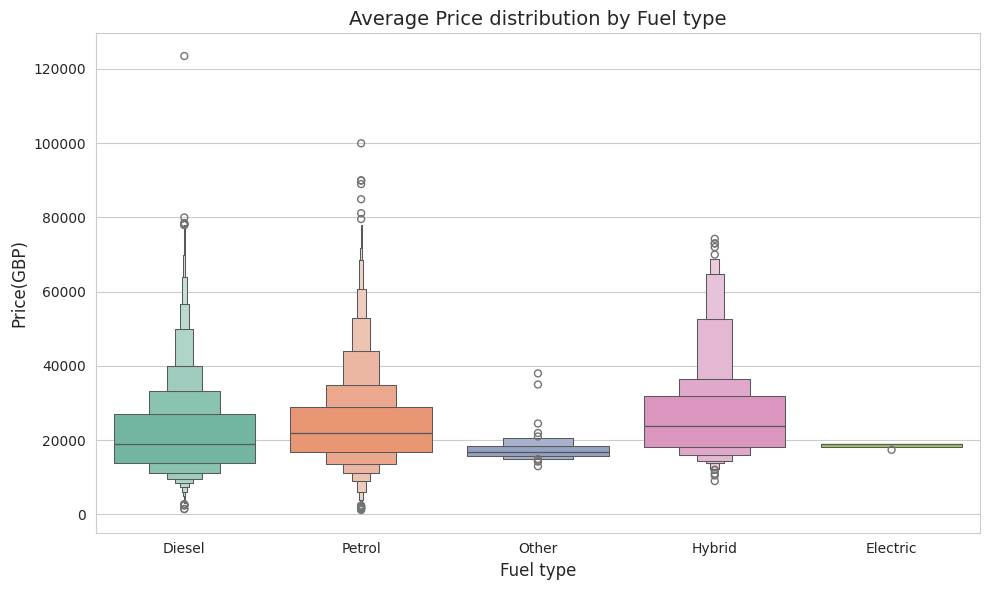

======연료 종류별 가격 분포======
fuelType
Diesel      21779.262986
Electric    18466.000000
Hybrid      27169.714765
Other       18193.861111
Petrol      24360.271583
Name: price, dtype: float64


In [31]:
# 연료 종류별 가격 분포
plt.figure(figsize=(10, 6))
sns.boxenplot(data=df, x='fuelType', y='price', palette='Set2')
plt.title('Average Price distribution by Fuel type', fontsize=14)
plt.xlabel('Fuel type', fontsize=12)
plt.ylabel('Price(GBP)', fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# 평균 가격 비교
fuel_price_avg = df.groupby('fuelType')['price'].mean()
print('======연료 종류별 가격 분포======')
print(fuel_price_avg)

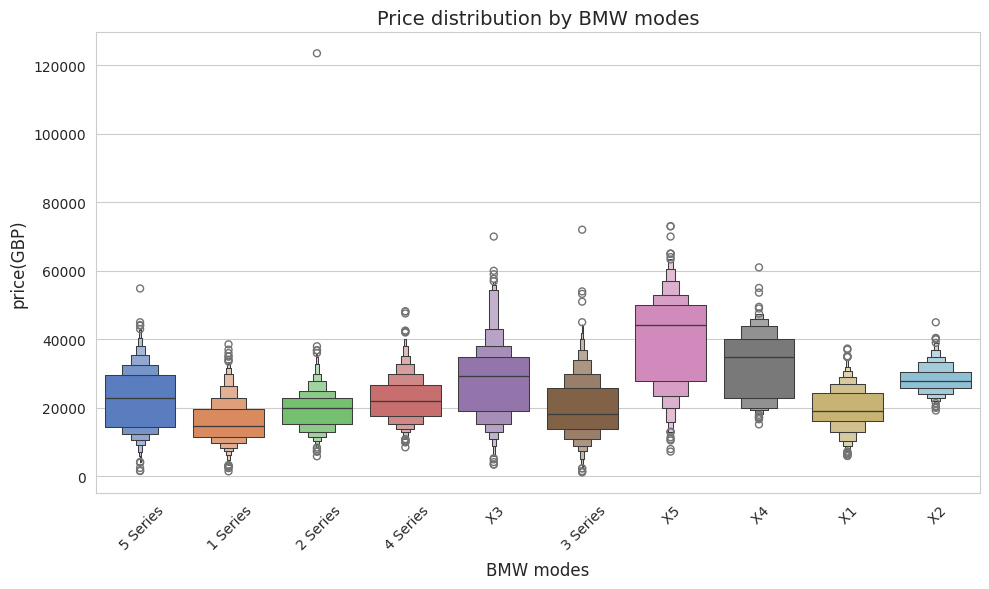

======상위 10개 BMW 모델별 평균 가격======
model
X7          69842.763636
8 Series    63997.794872
M5          57760.000000
i8          57012.588235
X6          43838.613208
M4          43274.232000
M2          43140.333333
X5          39651.196581
7 Series    36934.320755
X4          32721.335196
Name: price, dtype: float64


In [32]:
# 상위 10개 BMW 모델별 가격 분포
top_models = df['model'].value_counts().head(10).index
top_ten = df[df['model'].isin(top_models)]

plt.figure(figsize=(10, 6))
sns.boxenplot(data=top_ten, x='model', y='price', palette='muted')
plt.title('Price distribution by BMW modes', fontsize=14)
plt.xlabel('BMW modes', fontsize=12)
plt.ylabel('price(GBP)', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 평균 가격 비교
model_price_avg = df.groupby('model')['price'].mean().sort_values(ascending=False).head(10)
print('======상위 10개 BMW 모델별 평균 가격======')
print(model_price_avg)

1-5. EDA 저장

In [33]:
# EDA 저장
with open('EDA_summary.txt', 'w', encoding='utf-8') as f:
    f.write("=== BMW 중고차 데이터 EDA 요약 ===\n\n")
    f.write(f"총 데이터 개수: {len(df)}\n\n")
    f.write(df.describe().to_string())
    f.write("\n\n상관관계 (가격 기준):\n")
    f.write(price_corr.to_string())

print("EDA 요약이 'EDA_summary.txt'에 저장되었습니다.")

EDA 요약이 'EDA_summary.txt'에 저장되었습니다.


# 2. 데이터전처리

In [34]:
df = df_original.copy()
print(f"====현재 df.shape =====:{df.shape}")

====현재 df.shape =====:(10781, 9)


## 2-1. 결측치와 이상치 제거

2-1-1. 결측치제거

In [35]:
print(df.sum().isna())
# 결측치가 없음.
print(df.shape)

model           False
year            False
price           False
transmission    False
mileage         False
fuelType        False
tax             False
mpg             False
engineSize      False
dtype: bool
(10781, 9)


In [36]:
print(df.shape)

(10781, 9)


2-1-2. 이상치제거

In [37]:
df = df_original.copy()
print(df.shape)
df.describe()

(10781, 9)


,year,price,mileage,tax,mpg,engineSize
count,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000
mean,2017.078935,22733.408867,25496.986550,131.702068,56.399035,2.167767
std,2.349038,11415.528189,25143.192559,61.510755,31.336958,0.552054
min,1996.000000,1200.000000,1.000000,0.000000,5.500000,0.000000
25%,2016.000000,14950.000000,5529.000000,135.000000,45.600000,2.000000
50%,2017.000000,20462.000000,18347.000000,145.000000,53.300000,2.000000
75%,2019.000000,27940.000000,38206.000000,145.000000,62.800000,2.000000
max,2020.000000,123456.000000,214000.000000,580.000000,470.800000,6.600000


2-1-2-(1) 도메인 기반 이상치 제거

In [38]:
print(sum(df['price']>=90000), sum(df['mileage']>170000) ,sum(df['mpg']>450) ,sum(df['engineSize']==0))

2 3 43 47


In [39]:
# 'tax'는 IQR의 범위가 매우 좁으므로 제거하지 않음.
# 'year'는 추후에 'car_age'로 변경예정이라 제거하지 않음

def remove_outliers_domain(df):
  df = df.copy()
  nO = len(df)

  # ['price'] 0이하이거나 비정상적으로 큰 가격 제거
  df = df[(df['price']>0) & (df['price']<90000)]
  print(f"[price]제거: { nO - len(df)}개")
  nO = len(df)

  # ['mileage'] 0이하이거나 비정상적으로 큰 주행거리 제거
  df = df[(df['mileage']>0) & (df['mileage']<170000)]
  print(f"[mileage]제거: { nO - len(df)}개")
  nO = len(df)

  # ['mpg'] 0이하이거나 비정상적으로 큰 mpg제거
  df = df[(df['mpg']>0) & (df['mpg']<450)]
  print(f"[mpg]제거: { nO - len(df)}개")
  nO = len(df)

  # ['enginSize'] 0이하 제거(명백한 오류)
  df = df[(df['engineSize'])>0]
  print(f"[engineSize]제거: { nO - len(df)}개")
  nO = len(df)

  return df

df_domain = remove_outliers_domain(df)
print('도메인 기반 제거 후: ', df_domain.shape)

[price]제거: 2개
[mileage]제거: 3개
[mpg]제거: 43개
[engineSize]제거: 12개
도메인 기반 제거 후:  (10721, 9)


In [40]:
df = df_domain.copy()
print(df.shape)

(10721, 9)


## 2-2 피처 엔지니어링

In [41]:
# year -> car_age
df['car_age'] = 2026 - df['year']
df = df.drop(columns=['year'])
print(df.shape)

(10721, 9)


## 2-3 타깃 데이터 분리

In [42]:
y = df['price']
X = df.drop(columns=['price'])
print(X.shape, y.shape)

(10721, 8) (10721,)


## 2-4 train/test split

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
#(8576, 32) (2145, 32) (8576,) (2145,)
X_train.head(5)

(8576, 8) (2145, 8) (8576,) (2145,)


,model,transmission,mileage,fuelType,tax,mpg,engineSize,car_age
1648,X1,Manual,123,Diesel,145,68.9,2.0,7
1214,X2,Manual,103,Diesel,145,55.4,2.0,7
6039,3 Series,Semi-Auto,8748,Petrol,145,44.8,2.0,7
8864,3 Series,Automatic,12,Petrol,145,42.2,2.0,6
1357,2 Series,Automatic,123,Petrol,145,39.8,3.0,7


## 2-3. 인코딩

In [44]:
# #범주형 변수확인: unique가 50개 미만이므로 원핫인코딩 진행
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
print(X_train.shape, X_test.shape)
X_train.head(3)


(8576, 32) (2145, 32)


,mileage,tax,mpg,engineSize,car_age,model_ 2 Series,model_ 3 Series,model_ 4 Series,model_ 5 Series,model_ 6 Series,...,model_ X6,model_ X7,model_ Z3,model_ Z4,model_ i8,transmission_Manual,transmission_Semi-Auto,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
1648,123,145,68.9,2.0,7,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1214,103,145,55.4,2.0,7,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
6039,8748,145,44.8,2.0,7,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,True


# 3. 모델링

## 3-1. 랜덤포레스트

In [45]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

rf_model = RandomForestRegressor(random_state=0)
rf_model.fit(X_train, y_train)
y_val_pred = rf_model.predict(X_test)

mse = root_mean_squared_error(y_test, y_val_pred)
r2 = r2_score(y_test, y_val_pred)
print('rmse: ' ,mse)
print('r2: ' ,r2)

rmse:  2414.3459082145814
r2:  0.9522379256561768


##3-2. 선형회귀

In [46]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_val_pred_linear = lr_model.predict(X_test)

mse = root_mean_squared_error(y_test, y_val_pred_linear)
r2 = r2_score(y_test, y_val_pred_linear)
print('rmse: ' ,mse)
print('r2: ' ,r2)


rmse:  3787.6231057724412
r2:  0.8824513326733964


##3-3. GrandientBoostingRegressor

In [47]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=0)
gb_model.fit(X_train, y_train)
y_val_pred_gb = gb_model.predict(X_test)

mse = root_mean_squared_error(y_test, y_val_pred_gb)
r2 = r2_score(y_test, y_val_pred_gb)
print('rmse: ' ,mse)
print('r2: ' ,r2)

rmse:  3027.1040792959557
r2:  0.9249174693595122


#4. 교차검증

## 4-1. 과적합여부 검증

In [48]:
from sklearn.metrics import r2_score

def train_test_r2(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    r2_tr = r2_score(y_train, pred_train)
    r2_te = r2_score(y_test, pred_test)
    print(f"{name:18s} | R2 train: {r2_tr:.4f} | R2 test: {r2_te:.4f} | gap: {r2_tr - r2_te:.4f}")

train_test_r2(RandomForestRegressor(random_state=0),
              X_train, y_train, X_test, y_test, "RandomForest")
train_test_r2(GradientBoostingRegressor(random_state=0),
              X_train, y_train, X_test, y_test, "GradientBoosting")
train_test_r2(LinearRegression(),
              X_train, y_train, X_test, y_test, "LinearRegression")

RandomForest       | R2 train: 0.9934 | R2 test: 0.9522 | gap: 0.0411
GradientBoosting   | R2 train: 0.9407 | R2 test: 0.9249 | gap: 0.0158
LinearRegression   | R2 train: 0.8778 | R2 test: 0.8825 | gap: -0.0047


## 4-2 튜닝으로 과적합 보정

In [49]:
# RandomForest의 gap이 0.04이므로 깊이와 트리복잡도를 튜닝한다.
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

rf_model = RandomForestRegressor(random_state=0, max_depth=20, min_samples_leaf=5)
rf_model.fit(X_train, y_train)
y_val_pred_rf2 = rf_model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_val_pred_rf2)
r2 = r2_score(y_test, y_val_pred_rf2)
print('rmse: ' ,mse)
print('r2: ' ,r2)

rmse:  3027.1040792959557
r2:  0.9287565508300426


In [50]:
# gap 재검증
from sklearn.metrics import r2_score

def train_test_r2(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    r2_tr = r2_score(y_train, pred_train)
    r2_te = r2_score(y_test, pred_test)
    print(f"{name:18s} | R2 train: {r2_tr:.4f} | R2 test: {r2_te:.4f} | gap: {r2_tr - r2_te:.4f}")

train_test_r2(RandomForestRegressor(random_state=0,max_depth=20, min_samples_leaf=5),
              X_train, y_train, X_test, y_test, "RandomForest")

RandomForest       | R2 train: 0.9609 | R2 test: 0.9288 | gap: 0.0321


# 5. Feature Importance

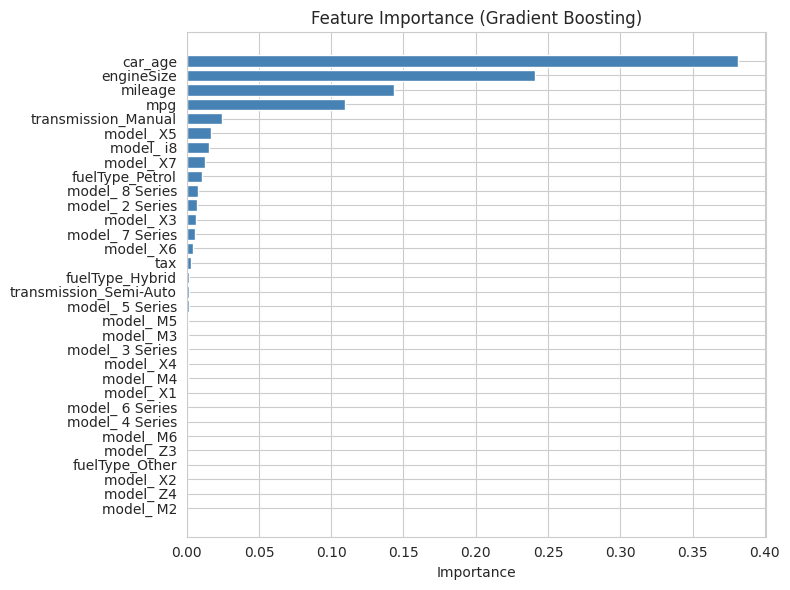

In [53]:
import matplotlib.pyplot as plt
import pandas as pd

# Feature Importance 추출
fi_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=True)

# 그래프 그리기
plt.figure(figsize=(8, 6))
plt.barh(fi_df['feature'], fi_df['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance (Gradient Boosting)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
